## Synthetic CMAB experiments

This notebook runs the synthetic part of the thesis using a regime-specific comparison:

| Synthetic environment | Baseline | Fair variant |
|---|---|---|
| deterministic | `LinUCB` | `FairLinUCB_DP` |
| stochastic | `LinTS` | `FairLinTS_DP` |
| adversarial  | `EXP4` | `FairEXP4_DP` |

The goal is to avoid comparing algorithms outside their intended assumptions. This notebook is therefore the main synthetic benchmark notebook.


### Imports and package check

In [1]:
from pathlib import Path
import json
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from fair_bandits.metrics.utility import utility_gap
from fair_bandits.metrics.fairness import equalized_odds_gap

from fair_bandits.config import build_config
from fair_bandits.data.synthetic import (
    make_synthetic_cmab_dataset,
    make_synthetic_expert_advice,
    quick_synthetic_diagnostics,
)
from fair_bandits.experiments import (
    run_regime_matched_synth_benchmark,
    make_synth_temporal_ci,
    make_synth_summary_table,
    compare_methods,
)
from fair_bandits.plots import plot_synth_temporal_metric

### Configuration

In [2]:
RUN_MODE = "full"  # change to "full" for final results

CFG = build_config(RUN_MODE)

SYNTHETIC_ROOT = CFG.results_dir / "synthetic_cmab_regime_matched"
SYNTHETIC_ROOT.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "dev":
    HORIZONS = (100, 250)
    SEEDS = tuple(range(3))
else:
    HORIZONS = (50, 100, 250, 500)
    SEEDS = tuple(range(CFG.n_seeds))

D = 10
N_EXPERTS = 6
CI_ALPHA = 0.10  # 90% CIs are narrower than the default 95% intervals

RUN_DIR = SYNTHETIC_ROOT / RUN_MODE
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Run mode:", RUN_MODE)
print("Horizons:", HORIZONS)
print("Seeds:", SEEDS)
print("CI alpha:", CI_ALPHA)
print("Output directory:", RUN_DIR)
CFG

Run mode: full
Horizons: (50, 100, 250, 500)
Seeds: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49)
CI alpha: 0.1
Output directory: results\full\synthetic_cmab_regime_matched\full


ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Sanity check: one synthetic environment

Checks that the generator produces a reasonable synthetic CMAB dataset and that expert advice has the expected shape for EXP4.

Dataframe head:


,t,group,oracle_action,oracle_prob,p_action_0,p_action_1
0,0,1,1,0.822496,0.122014,0.822496
1,1,1,1,0.853414,0.249726,0.853414
2,2,1,1,0.870431,0.202195,0.870431
3,3,1,1,0.824719,0.211172,0.824719
4,4,1,1,0.903161,0.256031,0.903161


X shape: (500, 10)
Group shape: (500,)
Oracle action shape: (500,)
Expert advice shape: (500, 6, 2)
Expert names: ['oracle_like', 'noisy_oracle', 'group0_positive_bias', 'group1_positive_bias', 'conservative_action0', 'random']
Config:
{'T': 500, 'd': 10, 'n_actions': 2, 'group_prob': 0.5, 'regime': 'adversarial_switching', 'reward_noise_std': 0.1, 'theta_scale': 1.0, 'bias_action1_group0': 0.45, 'bias_action1_group1': 0.15, 'bias_action0_group0': 0.0, 'bias_action0_group1': 0.0, 'context_mean_shift_group1': 0.0, 'clip_logits': 4.0, 'adversarial_block_size': 50, 'adversarial_shock_scale': 1.5, 'adversarial_flip_odd_blocks': True}

Group counts:
group
0    261
1    239
Name: count, dtype: int64

Oracle action distribution:
oracle_action
0    250
1    250
Name: count, dtype: int64

Mean oracle probability: 0.8307



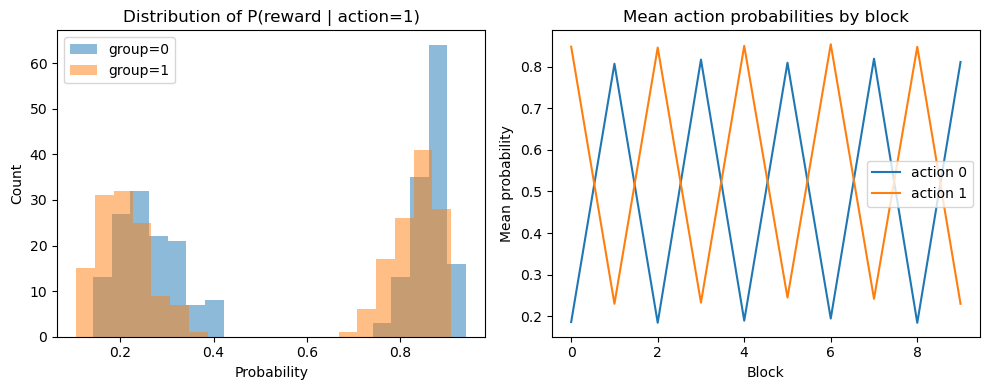

In [3]:
sanity = make_synthetic_cmab_dataset(
    T=500,
    d=D,
    regime="adversarial_switching",
    seed=42,
)

print("Dataframe head:")
display(sanity["df"].head())

print("X shape:", sanity["X"].shape)
print("Group shape:", sanity["group"].shape)
print("Oracle action shape:", sanity["y_opt"].shape)

expert_advice, expert_names = make_synthetic_expert_advice(
    sanity,
    n_experts=N_EXPERTS,
    seed=42,
)

print("Expert advice shape:", expert_advice.shape)
print("Expert names:", expert_names)

quick_synthetic_diagnostics(sanity)

### Run or load the regime-matched synthetic benchmark

The benchmark uses the following mapping:

- `stationary_deterministic`: `LinUCB` vs `FairLinUCB_DP`
- `stationary_stochastic`: `LinTS` vs `FairLinTS_DP`
- `adversarial_switching`: `EXP4` vs `FairEXP4_DP`


In [4]:
PERSEED_PATH = RUN_DIR / "perseed.csv"
CI_LONG_PATH = RUN_DIR / "ci_long.csv"
LOGS_PATH = RUN_DIR / "logs.csv"
TEMPORAL_PATH = RUN_DIR / "temporal_ci.csv"
SUMMARY_500_PATH = RUN_DIR / "summary_table_T500.csv"
METADATA_PATH = RUN_DIR / "metadata.json"

FORCE_RERUN = False

def _recompute_ci_long(perseed_df, alpha):
    metric_cols = [
        c
        for c in perseed_df.columns
        if c not in {"policy", "regime", "T", "seed"} and pd.api.types.is_numeric_dtype(perseed_df[c])
    ]
    rows = []
    for (regime, T, policy), gdf in perseed_df.groupby(["regime", "T", "policy"], dropna=False):
        for metric in metric_cols:
            vals = gdf[metric].to_numpy(dtype=float)
            rows.append({
                "regime": regime,
                "T": int(T),
                "policy": policy,
                "metric": metric,
                "mean": float(vals.mean()),
                "ci_low": float(np.quantile(vals, alpha / 2)),
                "ci_high": float(np.quantile(vals, 1 - alpha / 2)),
                "n_seeds": int(len(vals)),
            })
    return pd.DataFrame(rows)


def _recompute_temporal_ci(logs_df, alpha):
    if logs_df.empty:
        return pd.DataFrame()

    metric_map = {
        "avg_reward": "avg_reward",
        "rolling_reward": "rolling_reward",
        "DP_gap_over_time": "DP_gap",
        "cumulative_regret": "cum_regret",
    }

    rows = []
    for (regime, T, policy, t), gdf in logs_df.groupby(["regime", "T", "policy", "t"], dropna=False):
        for src_col, metric_name in metric_map.items():
            vals = gdf[src_col].to_numpy(dtype=float)
            rows.append({
                "regime": regime,
                "T": int(T),
                "policy": policy,
                "t": int(t),
                "metric": metric_name,
                "mean": float(vals.mean()),
                "ci_low": float(np.quantile(vals, alpha / 2)),
                "ci_high": float(np.quantile(vals, 1 - alpha / 2)),
                "n_seeds": int(len(vals)),
            })

    return pd.DataFrame(rows).sort_values(["regime", "T", "metric", "policy", "t"]).reset_index(drop=True)

cache_ready = (
    not FORCE_RERUN
    and PERSEED_PATH.exists()
    and CI_LONG_PATH.exists()
    and LOGS_PATH.exists()
    and TEMPORAL_PATH.exists()
)

if cache_ready:
    perseed = pd.read_csv(PERSEED_PATH)
    cached_seed_count = int(perseed["seed"].nunique()) if "seed" in perseed.columns else 0
    cache_ready = cached_seed_count == len(SEEDS)
    if not cache_ready:
        print(f"Cached benchmark has {cached_seed_count} seeds, expected {len(SEEDS)}. Recomputing.")

if cache_ready:
    ci_long = pd.read_csv(CI_LONG_PATH)
    logs = pd.read_csv(LOGS_PATH)
    temporal_ci = pd.read_csv(TEMPORAL_PATH)
    print("Loaded cached synthetic benchmark from:", RUN_DIR)
else:
    results = run_regime_matched_synth_benchmark(
        horizons=HORIZONS,
        seeds=SEEDS,
        d=D,
        dataset_overrides={},
        alpha_linucb=CFG.alpha_linucb,
        lambda_ridge=CFG.lambda_ridge,
        ts_v=0.5,
        exp4_gamma=0.07,
        dp_tau=CFG.dp_tau,
        dp_lambda_lin=CFG.dp_lambda,
        dp_lambda_exp4=0.20,
        beta_smooth=CFG.beta_smooth,
        min_group_count=CFG.min_group_count,
        n_experts=N_EXPERTS,
        keep_logs=True,
    )

    perseed = results["perseed"]
    ci_long = results["ci_long"]
    logs = results["logs"]
    temporal_ci = _recompute_temporal_ci(logs, alpha=CI_ALPHA)

    perseed.to_csv(PERSEED_PATH, index=False)
    ci_long.to_csv(CI_LONG_PATH, index=False)
    logs.to_csv(LOGS_PATH, index=False)
    temporal_ci.to_csv(TEMPORAL_PATH, index=False)

    metadata = {
        "run_mode": RUN_MODE,
        "horizons": list(HORIZONS),
        "seeds": list(SEEDS),
        "d": D,
        "n_experts": N_EXPERTS,
        "alpha_linucb": CFG.alpha_linucb,
        "lambda_ridge": CFG.lambda_ridge,
        "ts_v": 0.5,
        "exp4_gamma": 0.07,
        "dp_tau": CFG.dp_tau,
        "dp_lambda_lin": CFG.dp_lambda,
        "dp_lambda_exp4": 0.20,
        "beta_smooth": CFG.beta_smooth,
        "min_group_count": CFG.min_group_count,
    }
    with open(METADATA_PATH, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print("Saved synthetic benchmark to:", RUN_DIR)

ci_long = _recompute_ci_long(perseed, alpha=CI_ALPHA)
temporal_ci = _recompute_temporal_ci(logs, alpha=CI_ALPHA)
ci_long.to_csv(CI_LONG_PATH, index=False)
temporal_ci.to_csv(TEMPORAL_PATH, index=False)

print("perseed:", perseed.shape)
print("ci_long:", ci_long.shape)
print("logs:", logs.shape)
print("temporal_ci:", temporal_ci.shape)
print("CI alpha:", CI_ALPHA)

Loaded cached synthetic benchmark from: results\full\synthetic_cmab_regime_matched\full
perseed: (1200, 16)
ci_long: (264, 8)
logs: (270000, 19)
temporal_ci: (21600, 9)
CI alpha: 0.1


### Inspect outputs

In [5]:
display(perseed.head())
display(ci_long.head())
display(temporal_ci.head())

print("Regimes:", sorted(perseed["regime"].unique().tolist()))
print("Policies:", sorted(perseed["policy"].unique().tolist()))
print("Horizons:", sorted(perseed["T"].unique().tolist()))

,accuracy,DP_gap,TPR_gap,FPR_gap,EO_gap,PPV_gap,UtilityGap,CumulativeRegret,avg_reward,cumulative_regret,final_DP_gap_over_time,policy,regime,T,seed,algorithm_family
0,0.56,0.405844,0.484848,0.323864,0.484848,0.118056,0.094156,12.0,0.72,12.0,0.405844,LinUCB,stationary_deterministic,50,0,UCB
1,0.48,0.253247,0.393939,0.136364,0.393939,0.200000,0.084416,14.0,0.68,14.0,0.253247,FairLinUCB_DP,stationary_deterministic,50,0,UCB
2,0.74,0.090909,0.013072,0.370629,0.370629,0.390110,0.048701,8.0,0.80,8.0,0.090909,LinUCB,stationary_deterministic,50,1,UCB
3,0.74,0.090909,0.013072,0.370629,0.370629,0.390110,0.048701,8.0,0.80,8.0,0.090909,FairLinUCB_DP,stationary_deterministic,50,1,UCB
4,0.60,0.240385,0.500000,0.273810,0.500000,0.354167,0.128205,6.0,0.60,6.0,0.240385,LinUCB,stationary_deterministic,50,2,UCB


,regime,T,policy,metric,mean,ci_low,ci_high,n_seeds
0,adversarial_switching,50,EXP4,accuracy,0.744400,0.649000,0.811000,50
1,adversarial_switching,50,EXP4,DP_gap,0.088485,0.007128,0.227398,50
2,adversarial_switching,50,EXP4,TPR_gap,0.088485,0.007128,0.227398,50
3,adversarial_switching,50,EXP4,FPR_gap,0.000000,0.000000,0.000000,50
4,adversarial_switching,50,EXP4,EO_gap,0.088485,0.007128,0.227398,50


,regime,T,policy,t,metric,mean,ci_low,ci_high,n_seeds
0,adversarial_switching,50,EXP4,1,DP_gap,0.820000,0.0,1.00,50
1,adversarial_switching,50,EXP4,2,DP_gap,0.600000,0.0,1.00,50
2,adversarial_switching,50,EXP4,3,DP_gap,0.540000,0.0,1.00,50
3,adversarial_switching,50,EXP4,4,DP_gap,0.521667,0.0,1.00,50
4,adversarial_switching,50,EXP4,5,DP_gap,0.431000,0.0,0.91,50


Regimes: ['adversarial_switching', 'stationary_deterministic', 'stationary_stochastic']
Policies: ['EXP4', 'FairEXP4_DP', 'FairLinTS_DP', 'FairLinUCB_DP', 'LinTS', 'LinUCB']
Horizons: [50, 100, 250, 500]


### Summary table

The main thesis table should usually report the largest horizon. In `dev` mode the largest horizon is not necessarily 500, so we select the maximum available horizon automatically.


In [6]:
FINAL_T = int(max(perseed["T"].unique()))

summary_table = make_synth_summary_table(ci_long, T=FINAL_T)
display(summary_table)

summary_table.to_csv(RUN_DIR / f"summary_table_T{FINAL_T}.csv", index=False)
print("Saved:", RUN_DIR / f"summary_table_T{FINAL_T}.csv")

metric,regime,policy,DP_gap,EO_gap,PPV_gap,UtilityGap,accuracy,avg_reward,cumulative_regret
0,adversarial_switching,EXP4,0.041 ± 0.055,0.068 ± 0.057,0.043 ± 0.062,0.040 ± 0.046,0.733 ± 0.026,0.676 ± 0.030,81.152 ± 9.494
1,adversarial_switching,FairEXP4_DP,0.040 ± 0.057,0.067 ± 0.066,0.042 ± 0.067,0.031 ± 0.052,0.733 ± 0.031,0.668 ± 0.032,81.183 ± 8.334
2,stationary_deterministic,FairLinUCB_DP,0.030 ± 0.033,0.096 ± 0.069,0.160 ± 0.090,0.090 ± 0.051,0.736 ± 0.076,0.806 ± 0.061,44.440 ± 23.210
3,stationary_deterministic,LinUCB,0.037 ± 0.043,0.109 ± 0.078,0.163 ± 0.096,0.087 ± 0.043,0.738 ± 0.082,0.808 ± 0.058,43.700 ± 16.400
4,stationary_stochastic,FairLinTS_DP,0.030 ± 0.034,0.108 ± 0.117,0.173 ± 0.088,0.046 ± 0.064,0.558 ± 0.132,0.551 ± 0.043,21.990 ± 11.363
5,stationary_stochastic,LinTS,0.040 ± 0.047,0.107 ± 0.096,0.166 ± 0.069,0.050 ± 0.071,0.577 ± 0.104,0.544 ± 0.035,20.821 ± 10.100


Saved: results\full\synthetic_cmab_regime_matched\full\summary_table_T500.csv


### Regime-specific endpoint table

This table is easier to read than the long CI table because it keeps only the most important metrics.


In [7]:
METRICS_KEEP = [
    "accuracy",
    "avg_reward",
    "cumulative_regret",
    "DP_gap",
    "EO_gap",
    "PPV_gap",
    "UtilityGap",
]

endpoint = ci_long[
    (ci_long["T"] == FINAL_T)
    & (ci_long["metric"].isin(METRICS_KEEP))
].copy()

endpoint["mean_ci"] = endpoint.apply(
    lambda r: f"{r['mean']:.3f} [{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
    axis=1,
)

endpoint_table = endpoint.pivot_table(
    index=["regime", "policy"],
    columns="metric",
    values="mean_ci",
    aggfunc="first",
).reset_index()

display(endpoint_table)
endpoint_table.to_csv(RUN_DIR / f"endpoint_table_T{FINAL_T}.csv", index=False)

metric,regime,policy,DP_gap,EO_gap,PPV_gap,UtilityGap,accuracy,avg_reward,cumulative_regret
0,adversarial_switching,EXP4,"0.041 [0.006, 0.096]","0.068 [0.023, 0.125]","0.043 [0.004, 0.105]","0.040 [0.003, 0.087]","0.733 [0.703, 0.759]","0.676 [0.646, 0.706]","81.152 [72.476, 90.646]"
1,adversarial_switching,FairEXP4_DP,"0.040 [0.006, 0.097]","0.067 [0.021, 0.133]","0.042 [0.002, 0.109]","0.031 [0.002, 0.084]","0.733 [0.707, 0.764]","0.668 [0.632, 0.700]","81.183 [72.045, 89.518]"
2,stationary_deterministic,FairLinUCB_DP,"0.030 [0.003, 0.063]","0.096 [0.023, 0.165]","0.160 [0.038, 0.250]","0.090 [0.043, 0.142]","0.736 [0.647, 0.812]","0.806 [0.725, 0.867]","44.440 [24.900, 67.650]"
3,stationary_deterministic,LinUCB,"0.037 [0.004, 0.080]","0.109 [0.020, 0.187]","0.163 [0.056, 0.259]","0.087 [0.041, 0.131]","0.738 [0.643, 0.819]","0.808 [0.731, 0.866]","43.700 [23.700, 60.100]"
4,stationary_stochastic,FairLinTS_DP,"0.030 [0.002, 0.064]","0.108 [0.027, 0.225]","0.173 [0.082, 0.261]","0.046 [0.001, 0.109]","0.558 [0.408, 0.690]","0.551 [0.508, 0.594]","21.990 [12.266, 33.352]"
5,stationary_stochastic,LinTS,"0.040 [0.004, 0.086]","0.107 [0.026, 0.203]","0.166 [0.078, 0.235]","0.050 [0.002, 0.121]","0.577 [0.467, 0.681]","0.544 [0.508, 0.579]","20.821 [12.179, 30.921]"


### Grouped bar plots from CSV results

The plots below use the CSV summaries aggregated over all 50 seeds, so the bars show the mean and the error bars show the confidence interval computed from the full seed set.


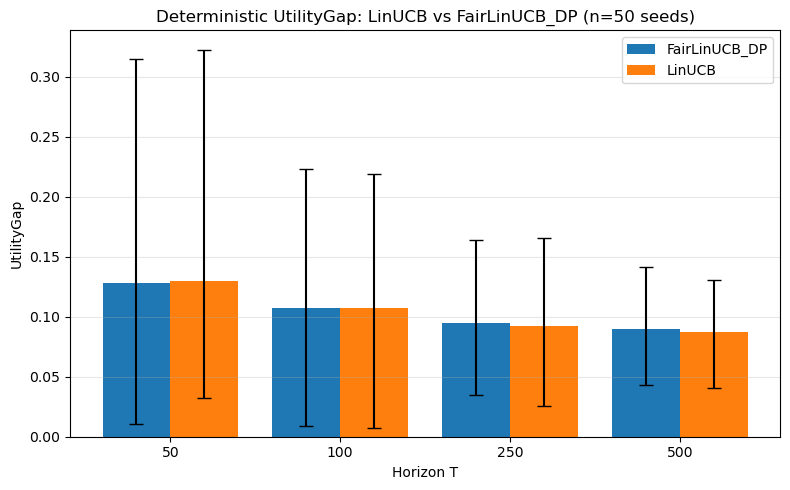

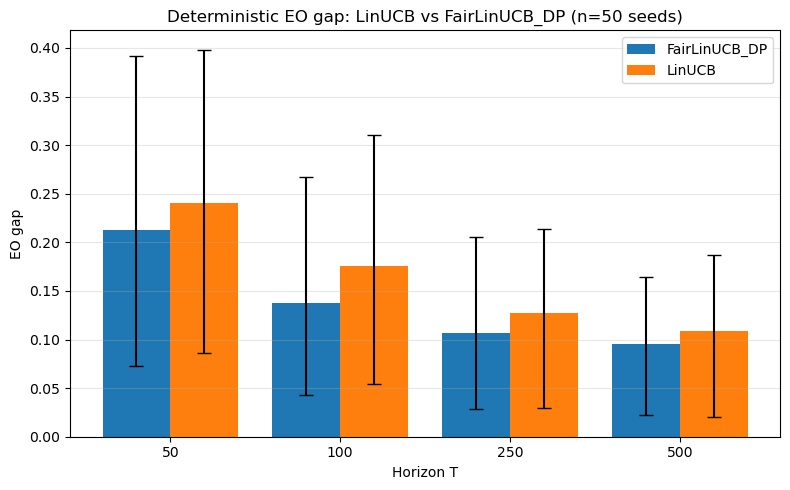

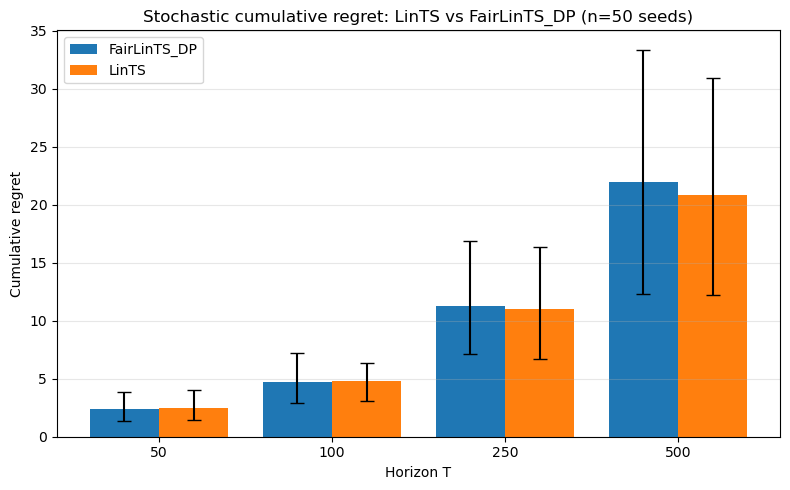

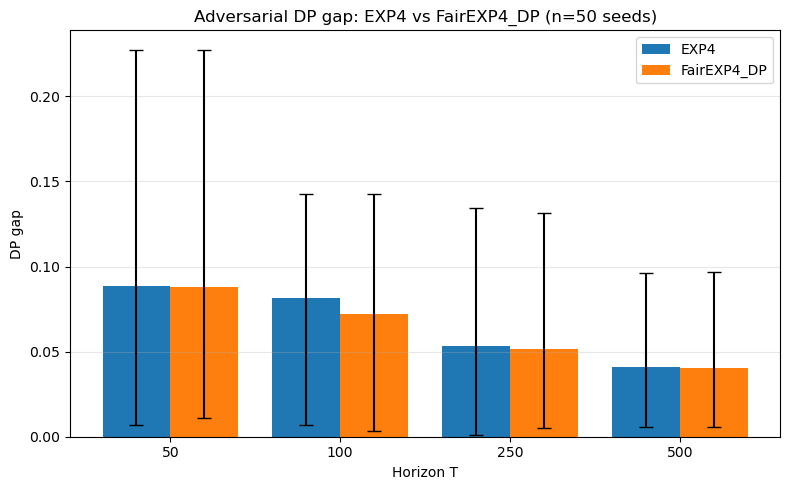

,regime,T,policy,metric,mean,ci_low,ci_high,n_seeds
1,adversarial_switching,50,EXP4,DP_gap,0.088485,0.007128,0.227398,50
12,adversarial_switching,50,FairEXP4_DP,DP_gap,0.087883,0.011263,0.227398,50
23,adversarial_switching,100,EXP4,DP_gap,0.081779,0.006965,0.142722,50
34,adversarial_switching,100,FairEXP4_DP,DP_gap,0.072160,0.003591,0.142722,50
45,adversarial_switching,250,EXP4,DP_gap,0.053043,0.001248,0.134383,50
56,adversarial_switching,250,FairEXP4_DP,DP_gap,0.051614,0.005084,0.131358,50
67,adversarial_switching,500,EXP4,DP_gap,0.040953,0.005564,0.096291,50
78,adversarial_switching,500,FairEXP4_DP,DP_gap,0.040361,0.005997,0.096990,50


In [8]:
def plot_grouped_bar_ci(ci_df, regime, metric, title, ylabel, save_path=None):
    sub = ci_df[(ci_df["regime"] == regime) & (ci_df["metric"] == metric)].copy()
    if sub.empty:
        raise ValueError(f"No data for regime={regime}, metric={metric}")

    horizons = sorted(sub["T"].unique().tolist())
    policies = sorted(sub["policy"].unique().tolist())
    x = np.arange(len(horizons), dtype=float)
    width = 0.8 / max(len(policies), 1)
    offsets = (np.arange(len(policies)) - (len(policies) - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(8, 5))
    for offset, policy in zip(offsets, policies):
        grp = sub[sub["policy"] == policy].set_index("T").reindex(horizons)
        means = grp["mean"].to_numpy(dtype=float)
        yerr = np.vstack([
            means - grp["ci_low"].to_numpy(dtype=float),
            grp["ci_high"].to_numpy(dtype=float) - means,
        ])
        ax.bar(
            x + offset,
            means,
            width=width,
            label=policy,
            yerr=yerr,
            capsize=5,
            edgecolor="none",
        )

    n_seeds = int(sub["n_seeds"].max()) if "n_seeds" in sub.columns else 0
    ax.set_xticks(x)
    ax.set_xticklabels([str(T) for T in horizons])
    ax.set_xlabel("Horizon T")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} (n={n_seeds} seeds)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(RUN_DIR / save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return sub


plot_grouped_bar_ci(
    ci_long,
    regime="stationary_deterministic",
    metric="UtilityGap",
    title="Deterministic UtilityGap: LinUCB vs FairLinUCB_DP",
    ylabel="UtilityGap",
    save_path="bar_deterministic_utilitygap_T500.png",
)

plot_grouped_bar_ci(
    ci_long,
    regime="stationary_deterministic",
    metric="EO_gap",
    title="Deterministic EO gap: LinUCB vs FairLinUCB_DP",
    ylabel="EO gap",
    save_path="bar_deterministic_eo_gap_T500.png",
)

plot_grouped_bar_ci(
    ci_long,
    regime="stationary_stochastic",
    metric="cumulative_regret",
    title="Stochastic cumulative regret: LinTS vs FairLinTS_DP",
    ylabel="Cumulative regret",
    save_path="bar_stochastic_regret_T500.png",
)

plot_grouped_bar_ci(
    ci_long,
    regime="adversarial_switching",
    metric="DP_gap",
    title="Adversarial DP gap: EXP4 vs FairEXP4_DP",
    ylabel="DP gap",
    save_path="bar_adversarial_dpgap_T500.png",
)


### Temporal plots

These figures show how reward, regret, and fairness evolve over rounds for each regime-specific comparison.


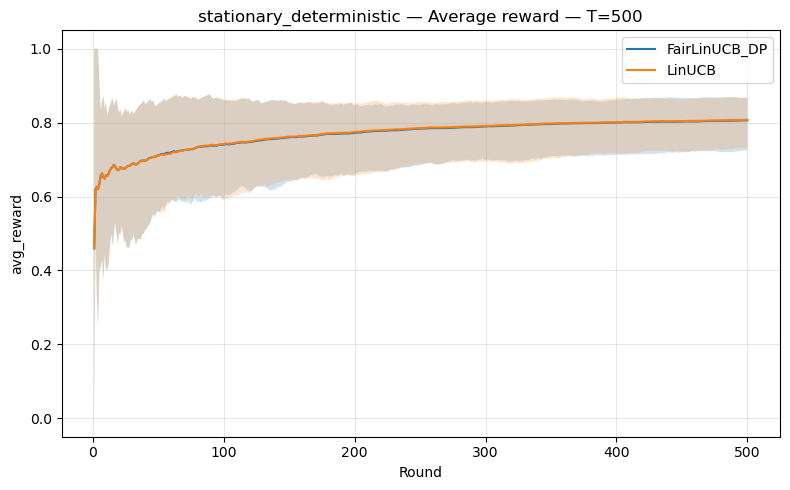

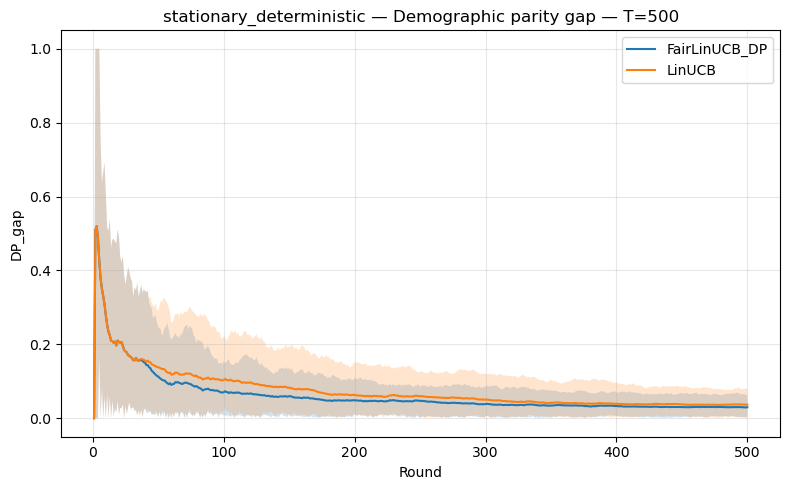

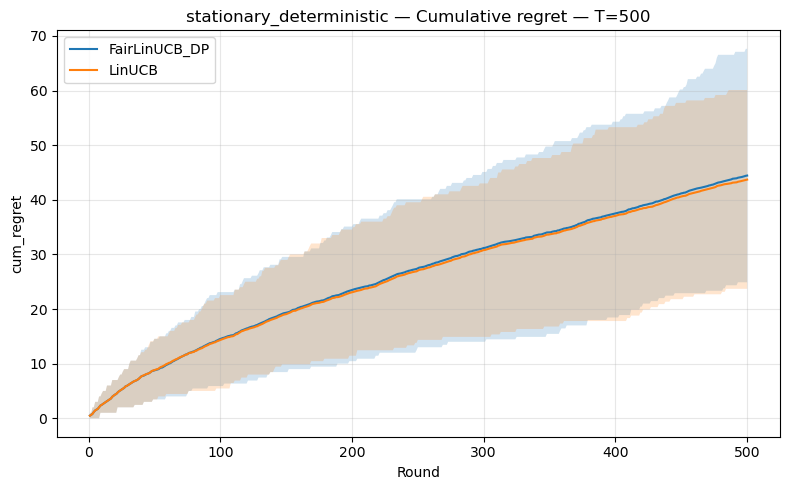

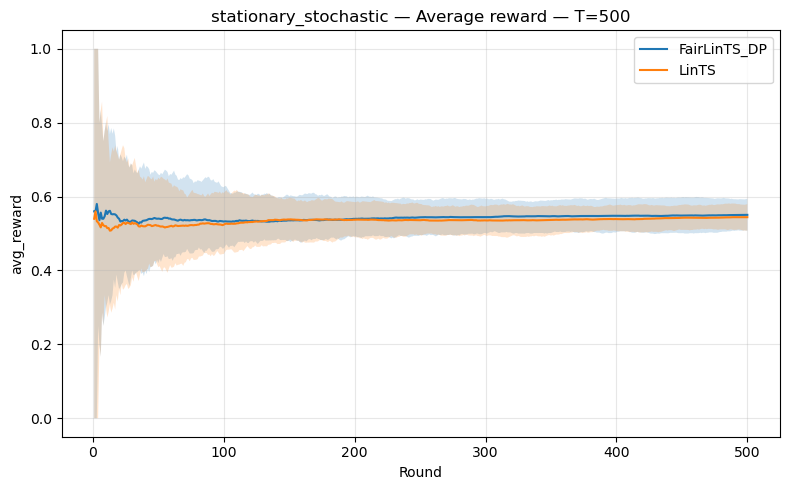

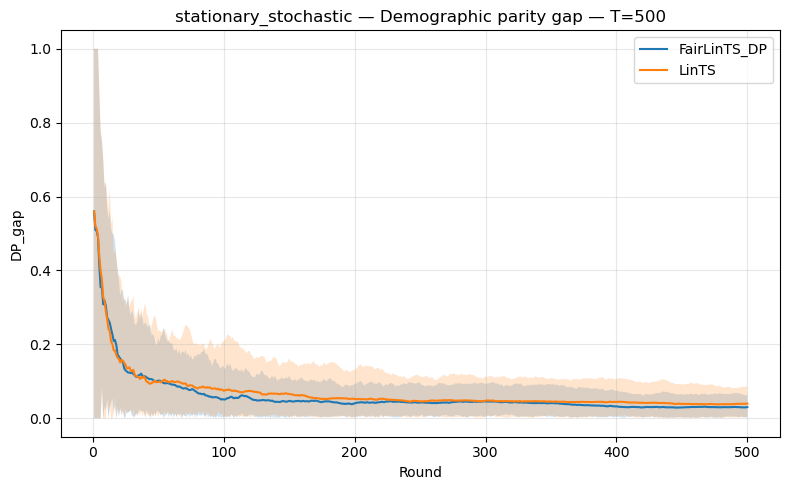

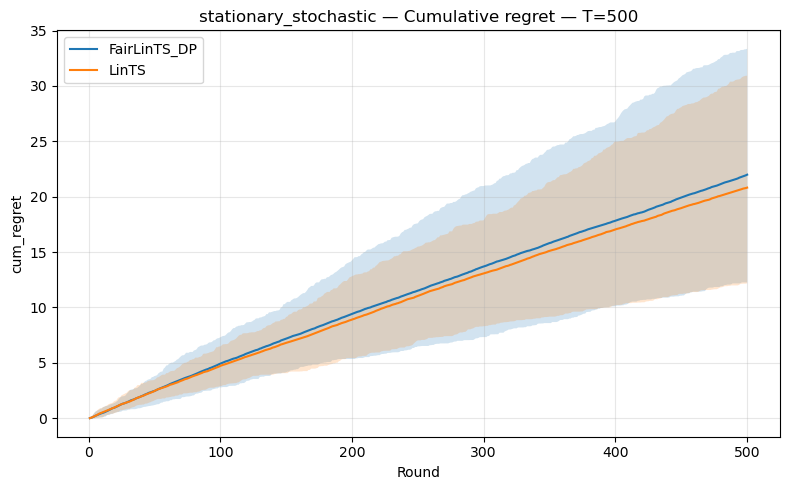

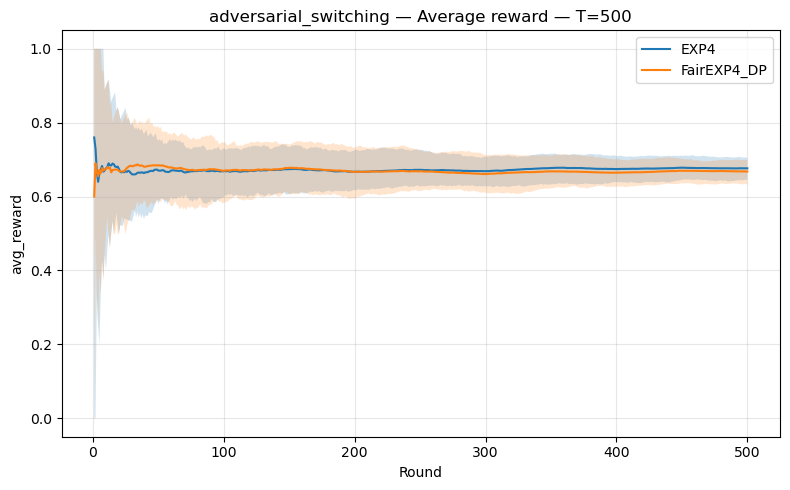

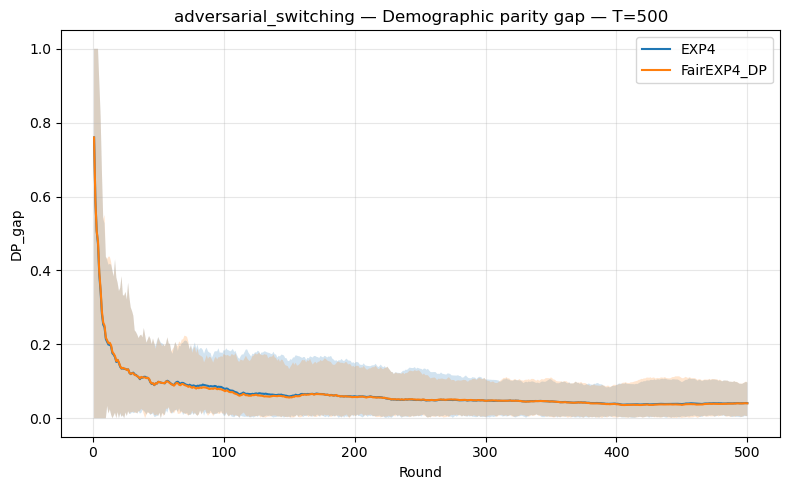

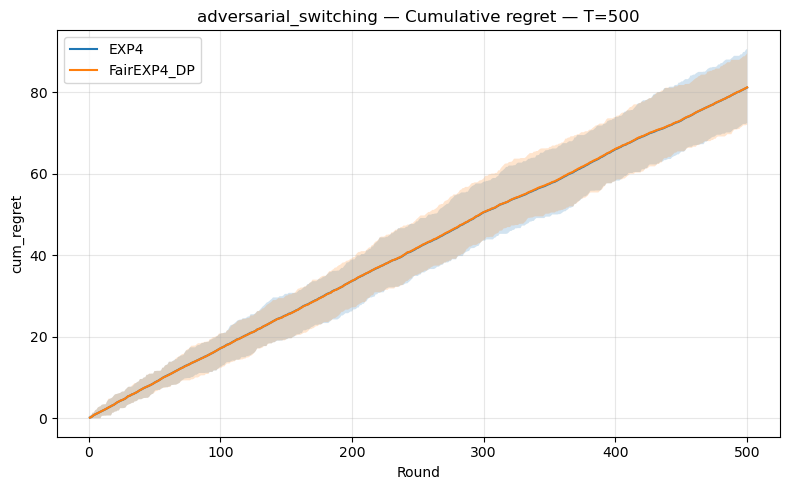

Saved temporal figures to: results\full\synthetic_cmab_regime_matched\full


In [9]:
POLICIES_BY_REGIME = {
    "stationary_deterministic": ["LinUCB", "FairLinUCB_DP"],
    "stationary_stochastic": ["LinTS", "FairLinTS_DP"],
    "adversarial_switching": ["EXP4", "FairEXP4_DP"],
}

METRICS_TO_PLOT = [
    ("avg_reward", "Average reward"),
    ("DP_gap", "Demographic parity gap"),
    ("cum_regret", "Cumulative regret"),
]

for regime, policies in POLICIES_BY_REGIME.items():
    for metric, label in METRICS_TO_PLOT:
        fig, ax = plt.subplots(figsize=(8, 5))
        plot_synth_temporal_metric(
            temporal_ci,
            regime=regime,
            T=FINAL_T,
            metric=metric,
            policies=policies,
            ax=ax,
            title=f"{regime} — {label} — T={FINAL_T}",
        )
        plt.tight_layout()
        out_path = RUN_DIR / f"temporal_{regime}_{metric}_T{FINAL_T}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

print("Saved temporal figures to:", RUN_DIR)

### Statistical comparisons

Because each regime compares only two methods, Wilcoxon signed-rank tests are the most relevant. Friedman tests are not informative for two-method comparisons.


In [10]:
STATS_METRICS = [
    ("avg_reward", False),
    ("cumulative_regret", True),
    ("DP_gap", True),
    ("EO_gap", True),
    ("UtilityGap", True),
]

stats_outputs = {}

for metric, lower_is_better in STATS_METRICS:
    _, wilcoxon_df = compare_methods(
        perseed,
        value_col=metric,
        method_col="policy",
        seed_col="seed",
        group_cols=["regime", "T"],
        lower_is_better=lower_is_better,
    )
    stats_outputs[metric] = wilcoxon_df
    out_path = RUN_DIR / f"wilcoxon_{metric}.csv"
    wilcoxon_df.to_csv(out_path, index=False)
    print(f"Saved {metric} tests to:", out_path)
    display(wilcoxon_df.head())



Saved avg_reward tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_avg_reward.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,avg_reward,EXP4,FairEXP4_DP,50,0.68320,0.69600,-0.01280,353.0,0.216973,FairEXP4_DP,0.216973
1,adversarial_switching,100,avg_reward,EXP4,FairEXP4_DP,50,0.65800,0.66500,-0.00700,465.0,0.293737,FairEXP4_DP,0.293737
2,adversarial_switching,250,avg_reward,EXP4,FairEXP4_DP,50,0.67592,0.66808,0.00784,414.0,0.048172,EXP4,0.048172
3,adversarial_switching,500,avg_reward,EXP4,FairEXP4_DP,50,0.67648,0.66788,0.00860,367.5,0.014780,EXP4,0.014780
4,stationary_deterministic,50,avg_reward,FairLinUCB_DP,LinUCB,50,0.71160,0.71080,0.00080,89.0,0.804469,FairLinUCB_DP,0.804469


Saved cumulative_regret tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_cumulative_regret.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,cumulative_regret,EXP4,FairEXP4_DP,50,8.438918,8.433715,0.005203,17.0,0.514670,FairEXP4_DP,0.514670
1,adversarial_switching,100,cumulative_regret,EXP4,FairEXP4_DP,50,17.107955,17.135431,-0.027476,157.0,0.638453,EXP4,0.638453
2,adversarial_switching,250,cumulative_regret,EXP4,FairEXP4_DP,50,41.950766,41.782876,0.167890,305.0,0.158146,FairEXP4_DP,0.158146
3,adversarial_switching,500,cumulative_regret,EXP4,FairEXP4_DP,50,81.152306,81.183486,-0.031180,591.0,0.830651,EXP4,0.830651
4,stationary_deterministic,50,cumulative_regret,FairLinUCB_DP,LinUCB,50,8.760000,8.800000,-0.040000,86.0,0.696389,FairLinUCB_DP,0.696389


Saved DP_gap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_DP_gap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,DP_gap,EXP4,FairEXP4_DP,50,0.088485,0.087883,0.000602,16.0,0.441268,FairEXP4_DP,0.441268
1,adversarial_switching,100,DP_gap,EXP4,FairEXP4_DP,50,0.081779,0.072160,0.009619,31.0,0.000674,FairEXP4_DP,0.000674
2,adversarial_switching,250,DP_gap,EXP4,FairEXP4_DP,50,0.053043,0.051614,0.001429,316.0,0.429297,FairEXP4_DP,0.429297
3,adversarial_switching,500,DP_gap,EXP4,FairEXP4_DP,50,0.040953,0.040361,0.000592,575.0,0.893928,FairEXP4_DP,0.893928
4,stationary_deterministic,50,DP_gap,FairLinUCB_DP,LinUCB,50,0.113046,0.138065,-0.025019,0.0,0.000059,FairLinUCB_DP,0.000059


Saved EO_gap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_EO_gap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,EO_gap,EXP4,FairEXP4_DP,50,0.088485,0.087883,0.000602,16.0,0.441268,FairEXP4_DP,0.441268
1,adversarial_switching,100,EO_gap,EXP4,FairEXP4_DP,50,0.137813,0.129290,0.008523,19.0,0.011272,FairEXP4_DP,0.011272
2,adversarial_switching,250,EO_gap,EXP4,FairEXP4_DP,50,0.093959,0.091528,0.002431,152.0,0.374043,FairEXP4_DP,0.374043
3,adversarial_switching,500,EO_gap,EXP4,FairEXP4_DP,50,0.067617,0.067070,0.000547,554.0,0.915724,FairEXP4_DP,0.915724
4,stationary_deterministic,50,EO_gap,FairLinUCB_DP,LinUCB,50,0.212607,0.240279,-0.027672,8.0,0.001184,FairLinUCB_DP,0.001184


Saved UtilityGap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_UtilityGap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,UtilityGap,EXP4,FairEXP4_DP,50,0.102641,0.094972,0.007669,474.0,0.242301,FairEXP4_DP,0.242301
1,adversarial_switching,100,UtilityGap,EXP4,FairEXP4_DP,50,0.087948,0.073457,0.014491,501.0,0.267377,FairEXP4_DP,0.267377
2,adversarial_switching,250,UtilityGap,EXP4,FairEXP4_DP,50,0.044713,0.048994,-0.004282,553.0,0.553942,EXP4,0.553942
3,adversarial_switching,500,UtilityGap,EXP4,FairEXP4_DP,50,0.040497,0.031090,0.009408,508.0,0.215052,FairEXP4_DP,0.215052
4,stationary_deterministic,50,UtilityGap,FairLinUCB_DP,LinUCB,50,0.128036,0.129546,-0.001510,84.5,0.672598,FairLinUCB_DP,0.672598


### Main Wilcoxon table at final horizon

In [11]:
final_stats = []

for metric, df_stat in stats_outputs.items():
    if df_stat.empty:
        continue
    sub = df_stat[df_stat["T"] == FINAL_T].copy()
    sub["metric"] = metric
    final_stats.append(sub)

if final_stats:
    final_stats_df = pd.concat(final_stats, ignore_index=True)
    display(final_stats_df)
    final_stats_df.to_csv(RUN_DIR / f"wilcoxon_final_T{FINAL_T}.csv", index=False)
else:
    final_stats_df = pd.DataFrame()
    print("No final-horizon statistics available.")

,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm,metric
0,adversarial_switching,500,avg_reward,EXP4,FairEXP4_DP,50,0.676480,0.667880,0.008600,367.5,0.014780,EXP4,0.014780,avg_reward
1,stationary_deterministic,500,avg_reward,FairLinUCB_DP,LinUCB,50,0.806440,0.807920,-0.001480,321.0,0.643489,LinUCB,0.643489,avg_reward
2,stationary_stochastic,500,avg_reward,FairLinTS_DP,LinTS,50,0.550520,0.544240,0.006280,526.5,0.283846,FairLinTS_DP,0.283846,avg_reward
3,adversarial_switching,500,cumulative_regret,EXP4,FairEXP4_DP,50,81.152306,81.183486,-0.031180,591.0,0.830651,EXP4,0.830651,cumulative_regret
4,stationary_deterministic,500,cumulative_regret,FairLinUCB_DP,LinUCB,50,44.440000,43.700000,0.740000,318.5,0.616157,LinUCB,0.616157,cumulative_regret
5,stationary_stochastic,500,cumulative_regret,FairLinTS_DP,LinTS,50,21.989669,20.820802,1.168868,546.0,0.382904,LinTS,0.382904,cumulative_regret
6,adversarial_switching,500,DP_gap,EXP4,FairEXP4_DP,50,0.040953,0.040361,0.000592,575.0,0.893928,FairEXP4_DP,0.893928,DP_gap
7,stationary_deterministic,500,DP_gap,FairLinUCB_DP,LinUCB,50,0.029707,0.036894,-0.007187,195.0,0.002275,FairLinUCB_DP,0.002275,DP_gap
8,stationary_stochastic,500,DP_gap,FairLinTS_DP,LinTS,50,0.030167,0.039591,-0.009424,419.0,0.054254,FairLinTS_DP,0.054254,DP_gap
9,adversarial_switching,500,EO_gap,EXP4,FairEXP4_DP,50,0.067617,0.067070,0.000547,554.0,0.915724,FairEXP4_DP,0.915724,EO_gap
